# Testes Estatísticos — TREC 2007

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ---------- Carregar dados ----------
DATA_DIR = '../../models/trec/'

with open(DATA_DIR + 'X_train_tfidf.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(DATA_DIR + 'X_test_tfidf.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(DATA_DIR + 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(DATA_DIR + 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

# ---------- Paleta de cores ----------
NAVY = '#1C2B4A'
TEAL = '#0891B2'
BLUE = '#2563EB'
GRAY = '#64748B'

# ---------- Definição dos modelos ----------
modelos = {
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
}

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')
print('Dados e modelos carregados com sucesso.')

/tmp/ipykernel_23364/2454569896.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


X_train: (59019, 10000)
X_test:  (14755, 10000)
y_train: (59019,)
y_test:  (14755,)
Dados e modelos carregados com sucesso.


In [2]:
# ---------- Validação cruzada estratificada (10 folds) ----------
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_cv = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    scores_cv[nome] = scores
    print(f'{nome}: F1 por fold = {np.round(scores, 4)}')

# DataFrame com F1-score por fold
df_cv = pd.DataFrame(scores_cv, index=[f'Fold {i+1}' for i in range(10)])
df_cv.index.name = 'Fold'
print()
df_cv

Naive Bayes: F1 por fold = [0.9655 0.9643 0.9614 0.9617 0.9591 0.9627 0.9625 0.9668 0.9657 0.9622]


SVM: F1 por fold = [0.9955 0.9935 0.9941 0.9936 0.9944 0.9946 0.9943 0.9955 0.9943 0.9946]


Random Forest: F1 por fold = [0.9959 0.9947 0.9931 0.9943 0.9936 0.9934 0.994  0.9941 0.994  0.9938]


Regressão Logística: F1 por fold = [0.9936 0.9915 0.9919 0.9922 0.991  0.9914 0.9915 0.9922 0.9923 0.9936]



,Naive Bayes,SVM,Random Forest,Regressão Logística
Fold,,,,
Fold 1,0.965517,0.995505,0.995885,0.993588
Fold 2,0.964290,0.993457,0.994733,0.991536
Fold 3,0.961411,0.994095,0.993057,0.991928
Fold 4,0.961722,0.993572,0.994343,0.992172
Fold 5,0.959130,0.994353,0.993582,0.991033
Fold 6,0.962707,0.994608,0.993449,0.991418
Fold 7,0.962520,0.994346,0.993963,0.991538
Fold 8,0.966786,0.995504,0.994086,0.992182
Fold 9,0.965691,0.994344,0.993953,0.992316


In [3]:
# ---------- Estatísticas descritivas ----------
desc_rows = []
for nome, scores in scores_cv.items():
    media = np.mean(scores)
    desvio = np.std(scores, ddof=1)
    minimo = np.min(scores)
    maximo = np.max(scores)
    n = len(scores)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    margem = t_crit * (desvio / np.sqrt(n))
    ci_inf = media - margem
    ci_sup = media + margem
    desc_rows.append({
        'Modelo': nome,
        'Média F1': round(media, 4),
        'Desvio Padrão': round(desvio, 4),
        'Mínimo': round(minimo, 4),
        'Máximo': round(maximo, 4),
        'IC 95% Inferior': round(ci_inf, 4),
        'IC 95% Superior': round(ci_sup, 4),
    })

df_desc = pd.DataFrame(desc_rows).set_index('Modelo')
print('Estatísticas descritivas dos F1-scores (10-fold CV):')
df_desc

Estatísticas descritivas dos F1-scores (10-fold CV):


,Média F1,Desvio Padrão,Mínimo,Máximo,IC 95% Inferior,IC 95% Superior
Modelo,,,,,,
Naive Bayes,0.9632,0.0023,0.9591,0.9668,0.9615,0.9649
SVM,0.9944,0.0007,0.9935,0.9955,0.9940,0.9949
Random Forest,0.9941,0.0008,0.9931,0.9959,0.9935,0.9946
Regressão Logística,0.9921,0.0009,0.9910,0.9936,0.9915,0.9927


In [4]:
# ---------- Teste de normalidade de Shapiro-Wilk ----------
print('Teste de Shapiro-Wilk (H0: distribuição normal)')
print('=' * 55)
for nome, scores in scores_cv.items():
    stat, p = stats.shapiro(scores)
    normalidade = 'Normal' if p > 0.05 else 'Não normal'
    print(f'{nome:25s}  W={stat:.4f}  p={p:.4f}  → {normalidade}')
print()
print('Se p > 0.05, não rejeitamos H0 (distribuição compatível com normal).')

Teste de Shapiro-Wilk (H0: distribuição normal)
Naive Bayes                W=0.9601  p=0.7867  → Normal
SVM                        W=0.9111  p=0.2883  → Normal
Random Forest              W=0.9058  p=0.2537  → Normal
Regressão Logística        W=0.8797  p=0.1296  → Normal

Se p > 0.05, não rejeitamos H0 (distribuição compatível com normal).


In [5]:
# ---------- Teste de Friedman ----------
nomes_modelos = list(scores_cv.keys())
arrays_scores = [scores_cv[n] for n in nomes_modelos]

stat_friedman, p_friedman = stats.friedmanchisquare(*arrays_scores)
print('Teste de Friedman (H0: todos os modelos têm desempenho igual)')
print(f'  Estatística χ² = {stat_friedman:.4f}')
print(f'  p-valor        = {p_friedman:.6f}')
print()
if p_friedman < 0.05:
    print('→ Rejeitamos H0: há diferença estatisticamente significativa entre os modelos.')
else:
    print('→ Não rejeitamos H0: não há evidência de diferença significativa entre os modelos.')

Teste de Friedman (H0: todos os modelos têm desempenho igual)
  Estatística χ² = 27.4800
  p-valor        = 0.000005

→ Rejeitamos H0: há diferença estatisticamente significativa entre os modelos.


In [6]:
# ---------- Testes par a par: McNemar (conjunto de teste) + Wilcoxon (CV) ----------
from itertools import combinations

# Obter predições no conjunto de teste para McNemar
predicoes = {}
for nome, modelo in modelos.items():
    modelo_treinado = modelo.__class__(**modelo.get_params())
    modelo_treinado.fit(X_train, y_train)
    predicoes[nome] = modelo_treinado.predict(X_test)

n_modelos = len(nomes_modelos)
n_pares = n_modelos * (n_modelos - 1) // 2  # para correção de Bonferroni

# --- Matrizes de p-valores ---
mcnemar_pvals = pd.DataFrame(
    np.ones((n_modelos, n_modelos)),
    index=nomes_modelos, columns=nomes_modelos
)
wilcoxon_pvals = pd.DataFrame(
    np.ones((n_modelos, n_modelos)),
    index=nomes_modelos, columns=nomes_modelos
)

print('Testes par a par (com correção de Bonferroni)')
print('=' * 70)

for i, j in combinations(range(n_modelos), 2):
    nome_a, nome_b = nomes_modelos[i], nomes_modelos[j]

    # --- McNemar ---
    pred_a = predicoes[nome_a]
    pred_b = predicoes[nome_b]
    # Tabela de contingência: correto/incorreto
    correto_a = (pred_a == y_test)
    correto_b = (pred_b == y_test)
    # b: A correto e B incorreto; c: A incorreto e B correto
    b = np.sum(correto_a & ~correto_b)
    c = np.sum(~correto_a & correto_b)
    # McNemar com correção de continuidade
    if b + c == 0:
        p_mcnemar = 1.0
    else:
        chi2_mcnemar = (abs(b - c) - 1) ** 2 / (b + c)
        p_mcnemar = stats.chi2.sf(chi2_mcnemar, df=1)
    p_mcnemar_bonf = min(p_mcnemar * n_pares, 1.0)
    mcnemar_pvals.loc[nome_a, nome_b] = p_mcnemar_bonf
    mcnemar_pvals.loc[nome_b, nome_a] = p_mcnemar_bonf

    # --- Wilcoxon ---
    diff = scores_cv[nome_a] - scores_cv[nome_b]
    if np.all(diff == 0):
        p_wilcoxon = 1.0
    else:
        _, p_wilcoxon = stats.wilcoxon(scores_cv[nome_a], scores_cv[nome_b])
    p_wilcoxon_bonf = min(p_wilcoxon * n_pares, 1.0)
    wilcoxon_pvals.loc[nome_a, nome_b] = p_wilcoxon_bonf
    wilcoxon_pvals.loc[nome_b, nome_a] = p_wilcoxon_bonf

    print(f'{nome_a} vs {nome_b}:')
    print(f'  McNemar  (Bonferroni): p = {p_mcnemar_bonf:.6f}')
    print(f'  Wilcoxon (Bonferroni): p = {p_wilcoxon_bonf:.6f}')
    print()

# Diagonal = NaN para clareza
np.fill_diagonal(mcnemar_pvals.values, np.nan)
np.fill_diagonal(wilcoxon_pvals.values, np.nan)

print('\nMatriz de p-valores — McNemar (Bonferroni):')
display(mcnemar_pvals.round(4))

print('\nMatriz de p-valores — Wilcoxon (Bonferroni):')
display(wilcoxon_pvals.round(4))

Testes par a par (com correção de Bonferroni)
Naive Bayes vs SVM:
  McNemar  (Bonferroni): p = 0.000000
  Wilcoxon (Bonferroni): p = 0.011719

Naive Bayes vs Random Forest:
  McNemar  (Bonferroni): p = 0.000000
  Wilcoxon (Bonferroni): p = 0.011719

Naive Bayes vs Regressão Logística:
  McNemar  (Bonferroni): p = 0.000000
  Wilcoxon (Bonferroni): p = 0.011719

SVM vs Random Forest:
  McNemar  (Bonferroni): p = 1.000000
  Wilcoxon (Bonferroni): p = 1.000000

SVM vs Regressão Logística:
  McNemar  (Bonferroni): p = 0.000008
  Wilcoxon (Bonferroni): p = 0.011719

Random Forest vs Regressão Logística:
  McNemar  (Bonferroni): p = 0.000052
  Wilcoxon (Bonferroni): p = 0.011719


Matriz de p-valores — McNemar (Bonferroni):


,Naive Bayes,SVM,Random Forest,Regressão Logística
Naive Bayes,NaN,0.0,0.0000,0.0000
SVM,0.0,NaN,1.0000,0.0000
Random Forest,0.0,1.0,NaN,0.0001
Regressão Logística,0.0,0.0,0.0001,NaN



Matriz de p-valores — Wilcoxon (Bonferroni):


,Naive Bayes,SVM,Random Forest,Regressão Logística
Naive Bayes,NaN,0.0117,0.0117,0.0117
SVM,0.0117,NaN,1.0000,0.0117
Random Forest,0.0117,1.0000,NaN,0.0117
Regressão Logística,0.0117,0.0117,0.0117,NaN


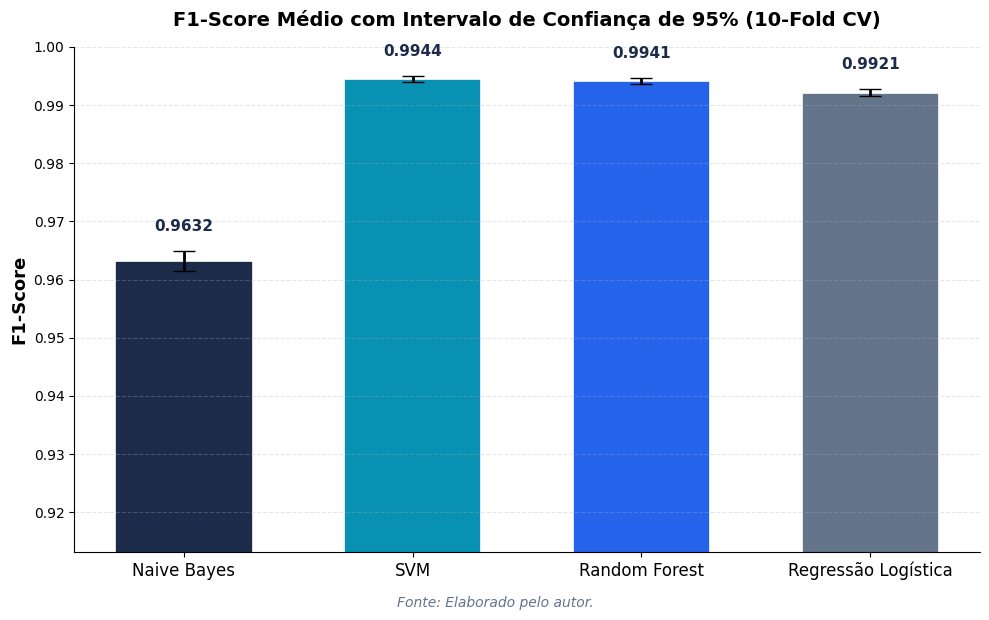

In [7]:
# ---------- Gráfico: F1-score com intervalo de confiança de 95% ----------
medias = []
erros = []
nomes_plot = []

for nome in nomes_modelos:
    scores = scores_cv[nome]
    media = np.mean(scores)
    desvio = np.std(scores, ddof=1)
    n = len(scores)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    margem = t_crit * (desvio / np.sqrt(n))
    medias.append(media)
    erros.append(margem)
    nomes_plot.append(nome)

cores = [NAVY, TEAL, BLUE, GRAY]

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(nomes_plot))

bars = ax.bar(x_pos, medias, yerr=erros, capsize=8, color=cores,
              edgecolor='white', linewidth=1.2, width=0.6,
              error_kw={'linewidth': 2, 'color': NAVY})

# Valor sobre cada barra
for i, (m, e) in enumerate(zip(medias, erros)):
    ax.text(i, m + e + 0.003, f'{m:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=NAVY)

ax.set_xticks(x_pos)
ax.set_xticklabels(nomes_plot, fontsize=12)
ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('F1-Score Médio com Intervalo de Confiança de 95% (10-Fold CV)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(bottom=min(medias) - 0.05, top=min(max(medias) + 0.05, 1.0))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.text(0.5, -0.02, 'Fonte: Elaborado pelo autor.', ha='center',
         fontsize=10, fontstyle='italic', color=GRAY)

plt.tight_layout()
plt.show()
fig_ci = fig

In [8]:
# ---------- Tabela resumo de significância ----------

def significancia(p):
    """Retorna estrelas de significância estatística."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# Construir tabela de comparações
sig_rows = []
for i, j in combinations(range(n_modelos), 2):
    nome_a, nome_b = nomes_modelos[i], nomes_modelos[j]
    p_mc = mcnemar_pvals.loc[nome_a, nome_b]
    p_wc = wilcoxon_pvals.loc[nome_a, nome_b]
    sig_rows.append({
        'Comparação': f'{nome_a} vs {nome_b}',
        'McNemar p-valor': round(p_mc, 6),
        'McNemar Sig.': significancia(p_mc),
        'Wilcoxon p-valor': round(p_wc, 6),
        'Wilcoxon Sig.': significancia(p_wc),
    })

df_sig = pd.DataFrame(sig_rows)
print('Tabela resumo de significância estatística')
print('Legenda: * p<0.05  |  ** p<0.01  |  *** p<0.001  |  ns = não significativo')
print('Correção de Bonferroni aplicada a todos os p-valores.')
print()
df_sig

Tabela resumo de significância estatística
Legenda: * p<0.05  |  ** p<0.01  |  *** p<0.001  |  ns = não significativo
Correção de Bonferroni aplicada a todos os p-valores.



,Comparação,McNemar p-valor,McNemar Sig.,Wilcoxon p-valor,Wilcoxon Sig.
0,Naive Bayes vs SVM,0.000000,***,0.011719,*
1,Naive Bayes vs Random Forest,0.000000,***,0.011719,*
2,Naive Bayes vs Regressão Logística,0.000000,***,0.011719,*
3,SVM vs Random Forest,1.000000,ns,1.000000,ns
4,SVM vs Regressão Logística,0.000008,***,0.011719,*
5,Random Forest vs Regressão Logística,0.000052,***,0.011719,*


Figura salva em: /home/edson-luiz/Projetos/TCC/figures/conclusions/f1_score_intervalo_confianca.png


Figura salva em: /home/edson-luiz/Projetos/TCC/figures/conclusions/tabela_significancia.png


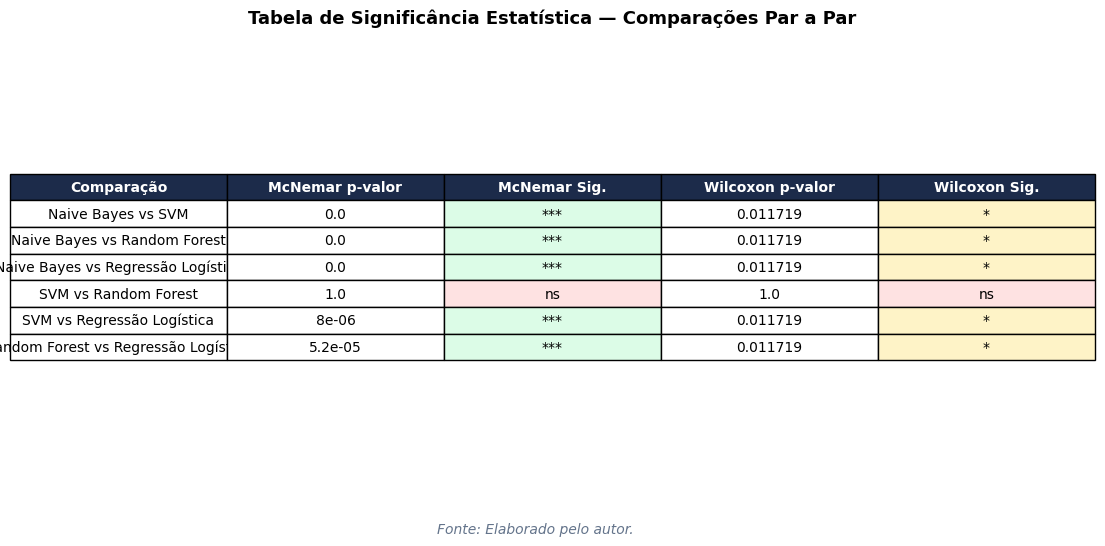


Todas as figuras salvas com sucesso.


In [9]:
# ---------- Salvar figuras ----------
import os

FIGURES_DIR = '../../figures/conclusions/'
os.makedirs(FIGURES_DIR, exist_ok=True)

fig_ci.savefig(
    FIGURES_DIR + 'f1_score_intervalo_confianca.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
print(f'Figura salva em: {os.path.abspath(FIGURES_DIR + "f1_score_intervalo_confianca.png")}')

# Salvar tabela de significância como figura
fig_tab, ax_tab = plt.subplots(figsize=(14, len(sig_rows) * 0.6 + 2))
ax_tab.axis('off')

colunas = df_sig.columns.tolist()
dados = df_sig.values.tolist()

tabela = ax_tab.table(
    cellText=dados,
    colLabels=colunas,
    cellLoc='center',
    loc='center'
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.0, 1.6)

# Estilizar cabeçalho
for j in range(len(colunas)):
    tabela[0, j].set_facecolor(NAVY)
    tabela[0, j].set_text_props(color='white', fontweight='bold')

# Colorir células de significância
for i in range(len(dados)):
    for j_col in [2, 4]:  # colunas de Sig.
        valor = dados[i][j_col]
        if valor == '***':
            tabela[i + 1, j_col].set_facecolor('#DCFCE7')
        elif valor == '**':
            tabela[i + 1, j_col].set_facecolor('#FEF9C3')
        elif valor == '*':
            tabela[i + 1, j_col].set_facecolor('#FEF3C7')
        else:
            tabela[i + 1, j_col].set_facecolor('#FEE2E2')

ax_tab.set_title('Tabela de Significância Estatística — Comparações Par a Par',
                 fontsize=13, fontweight='bold', pad=20)
fig_tab.text(0.5, 0.02, 'Fonte: Elaborado pelo autor.', ha='center',
             fontsize=10, fontstyle='italic', color=GRAY)

fig_tab.savefig(
    FIGURES_DIR + 'tabela_significancia.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
print(f'Figura salva em: {os.path.abspath(FIGURES_DIR + "tabela_significancia.png")}')

plt.show()
print('\nTodas as figuras salvas com sucesso.')